imdb sentiment - tf-idf + linearsvc baseline vs fine-tuned distilbert

point of this one is to see how much a transformer actually buys you over a classical baseline

In [3]:
import numpy as np
import torch
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device

C:\Users\Varun\anaconda3\envs\ml_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

In [4]:
imdb = load_dataset("stanfordnlp/imdb")
imdb

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [5]:
# full train set is 25k, thats plenty for the baseline
train_texts = imdb["train"]["text"]
train_labels = imdb["train"]["label"]
test_texts = imdb["test"]["text"]
test_labels = imdb["test"]["label"]

print(train_texts[0][:300])
print("label:", train_labels[0])  # 0 = neg, 1 = pos

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h
label: 0


## baseline - tf-idf + linearsvc

In [7]:
vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=20000)

X_train_tfidf = vectorizer.fit_transform(train_texts)
X_test_tfidf = vectorizer.transform(test_texts)

svc = LinearSVC()
svc.fit(X_train_tfidf, train_labels)

baseline_preds = svc.predict(X_test_tfidf)
baseline_acc = accuracy_score(test_labels, baseline_preds)
baseline_f1 = f1_score(test_labels, baseline_preds)

print("baseline acc:", baseline_acc)
print("baseline f1:", baseline_f1)
print(classification_report(test_labels, baseline_preds, target_names=["neg", "pos"]))

baseline acc: 0.8702
baseline f1: 0.8690000403697873
              precision    recall  f1-score   support

         neg       0.86      0.88      0.87     12500
         pos       0.88      0.86      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



## distilbert fine-tune

In [9]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments

model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

In [10]:
def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

# using a subset for fine-tuning since full 25k takes forever and doesnt change the story much
train_subset = imdb["train"].shuffle(seed=42).select(range(8000))
test_subset = imdb["test"].shuffle(seed=42).select(range(2000))

train_tok = train_subset.map(tokenize_fn, batched=True)
test_tok = test_subset.map(tokenize_fn, batched=True)

train_tok.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_tok.set_format("torch", columns=["input_ids", "attention_mask", "label"])

In [11]:
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 12953.78it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

In [13]:
args = TrainingArguments(
    output_dir="distilbert_imdb",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    compute_metrics=compute_metrics,
)

In [14]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.266350,0.261504,0.894000,0.894632
2,0.193903,0.357797,0.894500,0.895596


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.33it/s]


TrainOutput(global_step=1000, training_loss=0.25824838972091674, metrics={'train_runtime': 204.4762, 'train_samples_per_second': 78.249, 'train_steps_per_second': 4.891, 'total_flos': 1059739189248000.0, 'train_loss': 0.25824838972091674, 'epoch': 2.0})

In [15]:
results = trainer.evaluate()
results

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.193903,0.357797,2,0.894500,0.895596


{'eval_loss': 0.3577970564365387,
 'eval_accuracy': 0.8945,
 'eval_f1': 0.8955962394854032}

In [16]:
preds_output = trainer.predict(test_tok)
distilbert_preds = preds_output.predictions.argmax(-1)
distilbert_labels = preds_output.label_ids

print(classification_report(distilbert_labels, distilbert_preds, target_names=["neg", "pos"]))

              precision    recall  f1-score   support

         neg       0.90      0.88      0.89      1000
         pos       0.89      0.91      0.90      1000

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



## compare

In [18]:
print("tf-idf + linearsvc  -> acc:", baseline_acc, " f1:", baseline_f1)
print("distilbert finetuned -> acc:", results["eval_accuracy"], " f1:", results["eval_f1"])

# note: baseline trained on full 25k, distilbert trained on an 8k subset
# if comparing fairly later, retrain baseline on the same 8k subset too

tf-idf + linearsvc  -> acc: 0.8702  f1: 0.8690000403697873
distilbert finetuned -> acc: 0.8945  f1: 0.8955962394854032


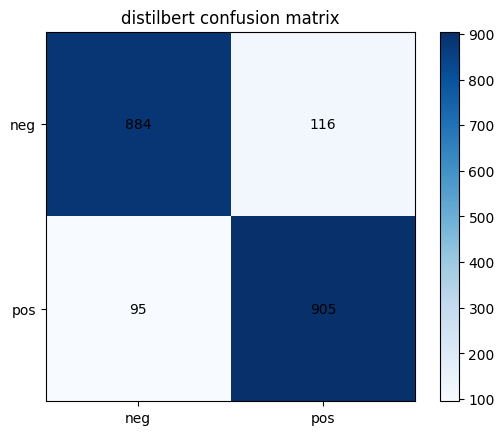

In [19]:
cm = confusion_matrix(distilbert_labels, distilbert_preds)
plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1], ["neg", "pos"])
plt.yticks([0, 1], ["neg", "pos"])
plt.colorbar()
plt.title("distilbert confusion matrix")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.savefig("distilbert_confusion.png")

## a few examples where the baseline and distilbert disagree

good for understanding what the transformer is actually picking up on that tf-idf misses

In [21]:
test_subset_texts = test_subset["text"]

# re-run baseline on just this subset so the comparison is apples to apples
baseline_preds_subset = svc.predict(vectorizer.transform(test_subset_texts))

disagreements = 0
for i in range(len(test_subset_texts)):
    if baseline_preds_subset[i] != distilbert_preds[i] and disagreements < 3:
        print("text:", test_subset_texts[i][:200])
        print("actual:", test_subset["label"][i], "| baseline:", baseline_preds_subset[i], "| distilbert:", distilbert_preds[i])
        print("---")
        disagreements += 1

text: This is the latest entry in the long series of films with the French agent, O.S.S. 117 (the French answer to James Bond). The series was launched in the early 1950's, and spawned at least eight films 
actual: 1 | baseline: 0 | distilbert: 1
---
text: After a very long time Marathi cinema has come with some good movie.This movie is one of the best Marathi movies ever made. It shows how a old grandfather tries to save his grandsons eye. He tries eve
actual: 1 | baseline: 0 | distilbert: 1
---
text: This is a really sad, and touching movie! It deals with the subject of child abuse. It's really sad, but mostly a true story, because it happens everyday. Elijah Wood and Joseph Mazzello play the two 
actual: 1 | baseline: 0 | distilbert: 1
---


## save

In [23]:
model.save_pretrained("distilbert_imdb_final")
tokenizer.save_pretrained("distilbert_imdb_final")
print("saved")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.04it/s]

saved
